<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Clase 23 de Abril
#### Jeremias Martin Pantozzi


VERIFICACIÓN DE POTENCIA
Señal: xx1 (Perfecto)
  > Potencia Temporal:    1.0000 W
  > Potencia Frecuencial: 1.0000 W
  > Error:                0.00e+00
Señal: xx2 (Desint. 0.25)
  > Potencia Temporal:    0.9990 W
  > Potencia Frecuencial: 0.9990 W
  > Error:                1.11e-16
Señal: xx3 (Desint. 0.5)
  > Potencia Temporal:    1.0000 W
  > Potencia Frecuencial: 1.0000 W
  > Error:                0.00e+00


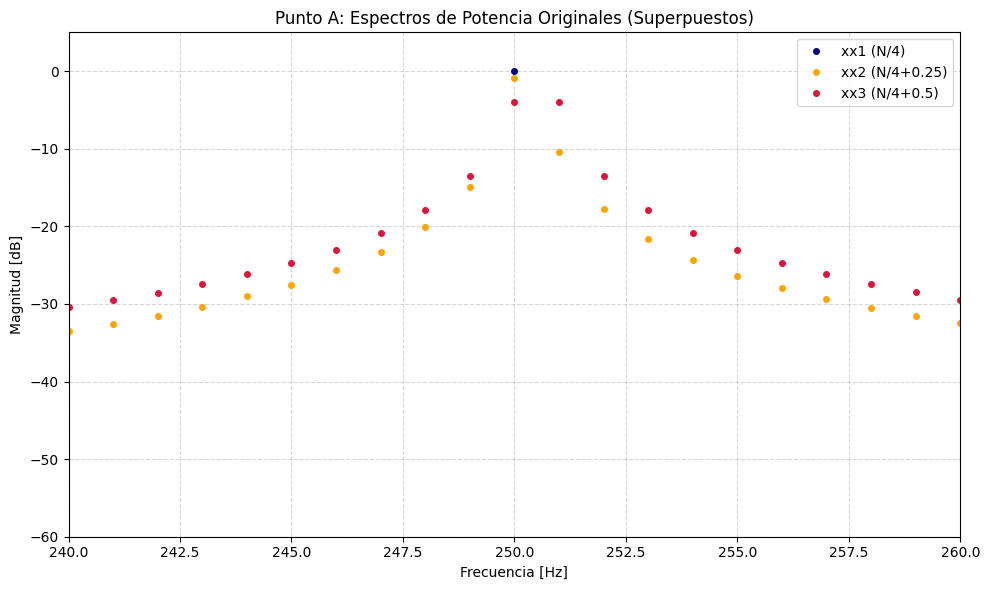

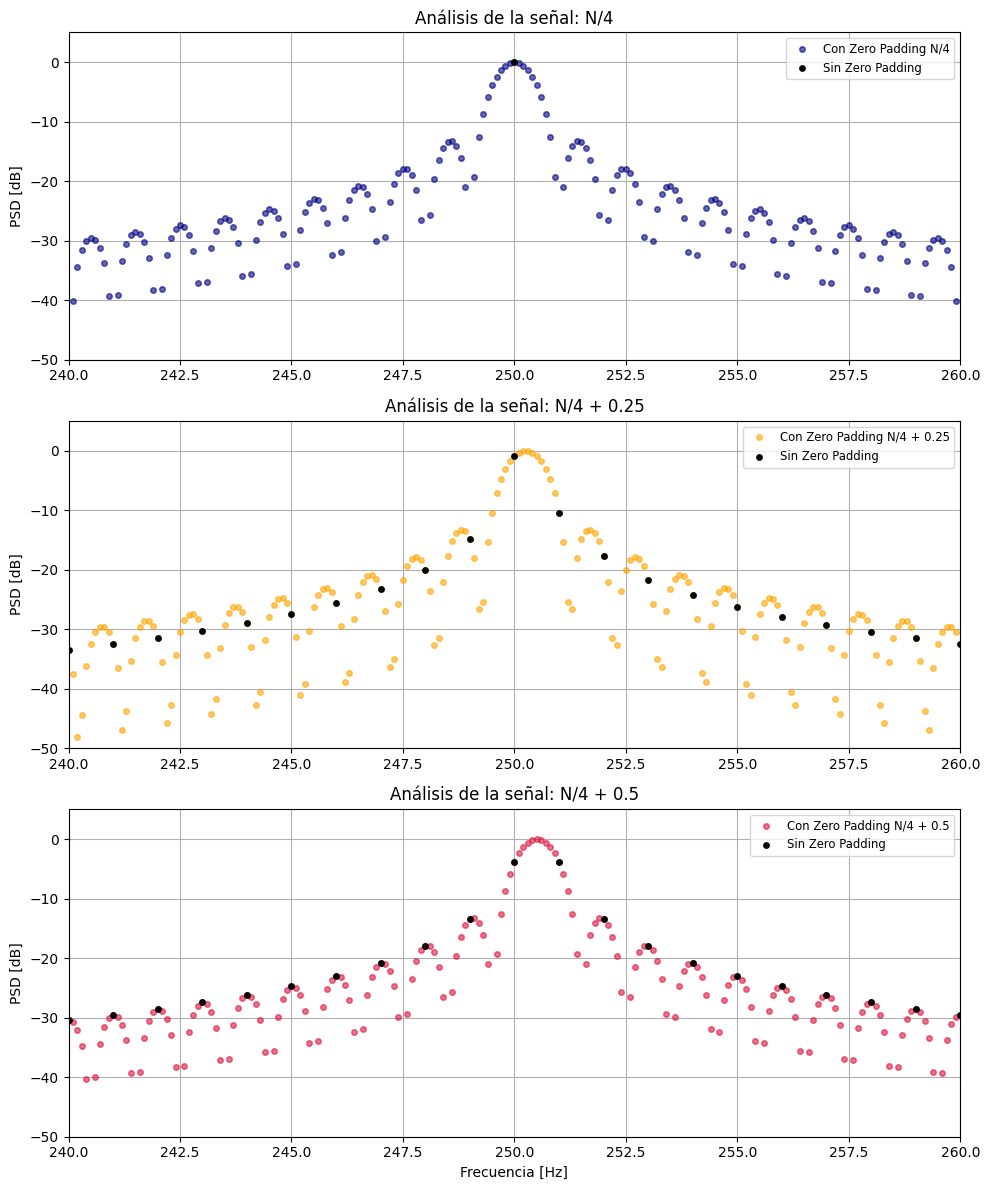

In [1]:
import matplotlib.pyplot as plt
import numpy as np

def mi_funcion_sen(vmax, dc, ff, ph, nn, fs):
    ts = 1 / fs
    tt = np.arange(0, nn) * ts
    xx = dc + vmax * np.sin(2 * np.pi * ff * tt + ph)
    return tt, xx

# %% --- CONFIGURACIÓN BASE ---

vmax = np.sqrt(2) 
dc = 0
ph = 0 
N = 1000
fs = N
df = fs/N
eps = 1e-12

# %% --- GENERACIÓN DE SEÑALES ---

ff1 = (N/4) * df
ff2 = ((N/4) + 0.25) * df
ff3 = ((N/4) + 0.5) * df

tt, xx1 = mi_funcion_sen(vmax, dc, ff1, ph, N, fs)
tt, xx2 = mi_funcion_sen(vmax, dc, ff2, ph, N, fs)
tt, xx3 = mi_funcion_sen(vmax, dc, ff3, ph, N, fs)

#eje de frecuencia
frec = np.arange(0, fs/2, df)

# %% --- CÁLCULO DE DFT ---

def calcular_potencia_db(señal):
    XX = np.fft.fft(señal)
    XXmod = np.abs(XX) / N #Normalizamos 
    # Multiplicamos por 2 para sumar la energía de la frecuencia negativa
    potencia_lineal = (XXmod**2) * 2 
    return 10 * np.log10(potencia_lineal + eps)

XXesp_db1 = calcular_potencia_db(xx1)
XXesp_db2 = calcular_potencia_db(xx2)
XXesp_db3 = calcular_potencia_db(xx3)

# %% ---VERIFICACION DE POTENCIAS POR PARSEVAL ---


print("VERIFICACIÓN DE POTENCIA")


señales = [xx1, xx2, xx3]
nombres = ["xx1 (Perfecto)", "xx2 (Desint. 0.25)", "xx3 (Desint. 0.5)"]

for señal, nombre in zip(señales, nombres):
    # 1. Potencia en el tiempo (Promedio del módulo al cuadrado)
    pot_temporal = np.mean(señal**2)
    
    # 2. Potencia en la frecuencia (Suma del espectro de potencia lineal)
    # Usamos la FFT sin recortar (los N puntos) y normalizada por N
    XX_lineal = np.fft.fft(señal)
    espectro_potencia = (np.abs(XX_lineal) / N)**2
    pot_frecuencial = np.sum(espectro_potencia)
    
    print(f"Señal: {nombre}")
    print(f"  > Potencia Temporal:    {pot_temporal:.4f} W")
    print(f"  > Potencia Frecuencial: {pot_frecuencial:.4f} W")
    print(f"  > Error:                {abs(pot_temporal - pot_frecuencial):.2e}")
 



# %% --- 3. PADDING UNIVERSAL ---

def procesar_padding_3(señal, cantidad_ceros_N):
    # La señal total será N (original) + cantidad * N (ceros)
    xx_p = np.concatenate((señal, np.zeros(cantidad_ceros_N * N)))
    
    # Calculamos el largo real de esta nueva señal
    n_largo = len(xx_p) 
    
    XX_p = np.fft.fft(xx_p)
    # Calibración Y: Seguimos normalizando por el N original (1000)
    XXmod_p = np.abs(XX_p) / N 
    return 10 * np.log10((XXmod_p**2) * 2 + eps), n_largo

l_pad = 9 # Cantidad de veces N que agregamos en ceros
XXesp_db1_p, N_total_pad = procesar_padding_3(xx1, l_pad)
XXesp_db2_p, N_total_pad = procesar_padding_3(xx2, l_pad)
XXesp_db3_p, N_total_pad = procesar_padding_3(xx3, l_pad)

# --- CALIBRACIÓN EJE X (Resolución Espectral) ---
# Ahora usamos N_total_pad que es el largo REAL (ej: 10000)
frec_pad = np.arange(0, fs/2, fs/N_total_pad)

# %% --- GRÁFICOS ---


# --- VENTANA 1: ESPECTROS SUPERPUESTOS ---
plt.figure(1, figsize=(10, 6))

# Definimos la configuración para el bucle
config = [
    (XXesp_db1, 'navy', 'xx1 (N/4)'), 
    (XXesp_db2, 'orange', 'xx2 (N/4+0.25)'), 
    (XXesp_db3, 'crimson', 'xx3 (N/4+0.5)')
]

for data, col, lab in config:
   
    plt.plot(frec, data[:N//2], 'o', color=col, label=lab, markersize=4)

plt.title('Punto A: Espectros de Potencia Originales (Superpuestos)')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Magnitud [dB]')

# Límites y grilla
plt.xlim(240, 260) #para ver solo el lobulo principal (se que va a estar en 250 porque es fs/4 y fs es 1000)
plt.ylim(-60, 5) # Un poco de margen sobre el 0
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()

plt.tight_layout()

# --- VENTANA 2: COMPARATIVA INDIVIDUAL CON ZERO PADDING (Punto C) ---
fig2, ax2 = plt.subplots(3, 1, figsize=(10, 12))

# Datos para el bucle
datos_orig = [XXesp_db1, XXesp_db2, XXesp_db3]
datos_pad = [XXesp_db1_p, XXesp_db2_p, XXesp_db3_p]
colores = ['navy', 'orange', 'crimson']
labels = ['N/4', 'N/4 + 0.25', 'N/4 + 0.5']

for i in range(3):
    # 1. Graficamos la envolvente (Zero Padding) - Usamos línea o puntos muy chicos
    ax2[i].plot(frec_pad, datos_pad[i][:N_total_pad//2],'o', color=colores[i],markersize=4,alpha=0.6, label=f'Con Zero Padding {labels[i]}')
    
    # 2. Graficamos los bins originales (Sin Padding) - Puntos grandes
    # Usamos scatter para que se note que son las muestras originales
    ax2[i].scatter(frec, datos_orig[i][:N//2], color='black', s=15, label='Sin Zero Padding', zorder=5)
    
    # Configuración de cada subplot
    ax2[i].set_title(f'Análisis de la señal: {labels[i]}')
    ax2[i].set_ylabel('PSD [dB]')
    ax2[i].set_xlim(240, 260) # Zoom para ver el lóbulo principal y laterales
    ax2[i].set_ylim(-50, 5)
    ax2[i].grid(True)
    ax2[i].legend(loc='upper right', fontsize='small')

ax2[2].set_xlabel('Frecuencia [Hz]')
plt.tight_layout()
plt.show()